#📌 Extracción

In [17]:
import pandas as pd
import requests

# URL del dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Realizamos la petición HTTP GET
response = requests.get(url)

# Verificamos que la petición fue exitosa (código 200 = OK)
print(f"Status code: {response.status_code}")

Status code: 200


In [18]:
# Convertimos el JSON a un DataFrame de pandas
from io import StringIO
df = pd.read_json(StringIO(response.text))

In [19]:
# Primera exploración del dataset
print(f"\n✅ Datos cargados correctamente")
print(f"📐 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n🔍 Primeras 5 filas:")
df.head()


✅ Datos cargados correctamente
📐 Dimensiones del dataset: 7267 filas x 6 columnas

🔍 Primeras 5 filas:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [21]:
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,0002-ORFBO,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


<p> Se encuentran Diccionarios y posiblemente se deban actualizar tipos de datos </p>

#🔧 Transformación

In [22]:
# 🔧 Transformación
# Paso 1: Normalizar columnas anidadas (diccionarios)
# En la exploración detectamos que customer, phone, internet y account
# contienen diccionarios. Los aplanamos con json_normalize()

customer_df = pd.json_normalize(df['customer'])
phone_df    = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df  = pd.json_normalize(df['account'])

# Unimos todo en un DataFrame plano
df_clean = pd.concat(
    [df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df],
    axis=1
)

print(f"✅ Normalización completada")
print(f"📐 Dimensiones: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\n🔍 Columnas resultantes:")
print(df_clean.columns.tolist())

✅ Normalización completada
📐 Dimensiones: 7267 filas x 21 columnas

🔍 Columnas resultantes:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [23]:
# Paso 2: Explorar tipos de datos y estructura
# Consultamos el diccionario de datos para entender cada columna
# y verificamos si los tipos son los correctos

print("📋 Tipos de datos por columna:")
print(df_clean.dtypes)
print(f"\n📐 Shape: {df_clean.shape}")
df_clean.head()

📋 Tipos de datos por columna:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object

📐 Shape: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [24]:
# Paso 3: Comprobación de inconsistencias
# Buscamos: valores nulos, duplicados, categorías raras

# 3a. Valores nulos
print("🔍 Valores nulos por columna:")
print(df_clean.isnull().sum())

# 3b. Filas duplicadas
duplicados = df_clean.duplicated().sum()
print(f"\n🔁 Filas duplicadas: {duplicados}")

# 3c. Valores únicos en columna objetivo
print(f"\n🎯 Valores únicos en 'Churn': {df_clean['Churn'].unique()}")

# 3d. Revisamos Charges.Total por si tiene valores vacíos o strings
print(f"\n💰 Valores únicos problemáticos en 'Charges.Total':")
print(df_clean[df_clean['Charges.Total'] == '']['Charges.Total'].count(), "registros vacíos")

🔍 Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

🔁 Filas duplicadas: 0

🎯 Valores únicos en 'Churn': ['No' 'Yes' '']

💰 Valores únicos problemáticos en 'Charges.Total':
0 registros vacíos


In [25]:
# Verificar valores unicos en TODAS las columnas categoricas
print("🔍 Revision de valores unicos por columna:\n")
for col in df_clean.select_dtypes(include='object').columns:
    unicos = df_clean[col].value_counts(dropna=False)
    print(f"--- {col} ---")
    print(unicos)
    print()

🔍 Revision de valores unicos por columna:

--- customerID ---
customerID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7267, dtype: int64

--- Churn ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- gender ---
gender
Male      3675
Female    3592
Name: count, dtype: int64

--- Partner ---
Partner
No     3749
Yes    3518
Name: count, dtype: int64

--- Dependents ---
Dependents
No     5086
Yes    2181
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6560
No      707
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No  

In [26]:
# Paso 4: Manejo de inconsistencias
# Aplicamos correcciones según lo encontrado

# 4a. Charges.Total tiene espacios vacíos '' → convertir a NaN y luego a float
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# 4b. Rellenar NaN en Charges.Total con 0 (clientes nuevos sin cobros aún)
df_clean['Charges.Total'] = df_clean['Charges.Total'].fillna(0)

# 4c. Eliminar filas duplicadas si existen
df_clean = df_clean.drop_duplicates()

# 4d. Limpiar espacios en columnas de texto (buena práctica)
cols_texto = df_clean.select_dtypes(include='object').columns
for col in cols_texto:
    df_clean[col] = df_clean[col].str.strip()

print("✅ Inconsistencias corregidas")
print(f"📐 Dimensiones finales: {df_clean.shape}")
print(f"\n🔍 Nulos restantes:\n{df_clean.isnull().sum()}")

✅ Inconsistencias corregidas
📐 Dimensiones finales: (7267, 21)

🔍 Nulos restantes:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [27]:
# Paso 5 (Opcional): Crear columna 'Cuentas_Diarias'
# Dividimos la facturación mensual entre 30 para obtener el valor diario

df_clean['Cuentas_Diarias'] = (df_clean['Charges.Monthly'] / 30).round(2)

print("✅ Columna 'Cuentas_Diarias' creada")
print(df_clean[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

✅ Columna 'Cuentas_Diarias' creada
   customerID  Charges.Monthly  Cuentas_Diarias
0  0002-ORFBO             65.6             2.19
1  0003-MKNFE             59.9             2.00
2  0004-TLHLJ             73.9             2.46
3  0011-IGKFF             98.0             3.27
4  0013-EXCHZ             83.9             2.80


In [28]:
# Paso 6 (Opcional): Estandarización y traducción de datos
# Convertimos Yes/No a 1/0 para facilitar análisis numérico
# y renombramos columnas al español para mejor comunicación

# 6a. Mapear Yes/No → 1/0 en columnas binarias
cols_binarias = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]
for col in cols_binarias:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).fillna(df_clean[col])

# 6b. SeniorCitizen ya es 0/1, solo verificamos
print(f"Valores únicos SeniorCitizen: {df_clean['SeniorCitizen'].unique()}")

# 6c. Renombrar columnas al español
df_clean = df_clean.rename(columns={
    'customerID'         : 'ID_Cliente',
    'Churn'              : 'Evasion',
    'gender'             : 'Genero',
    'SeniorCitizen'      : 'Adulto_Mayor',
    'Partner'            : 'Pareja',
    'Dependents'         : 'Dependientes',
    'tenure'             : 'Meses_Contrato',
    'PhoneService'       : 'Servicio_Telefono',
    'MultipleLines'      : 'Multiples_Lineas',
    'InternetService'    : 'Servicio_Internet',
    'OnlineSecurity'     : 'Seguridad_Online',
    'OnlineBackup'       : 'Respaldo_Online',
    'DeviceProtection'   : 'Proteccion_Dispositivo',
    'TechSupport'        : 'Soporte_Tecnico',
    'StreamingTV'        : 'Streaming_TV',
    'StreamingMovies'    : 'Streaming_Peliculas',
    'Contract'           : 'Tipo_Contrato',
    'PaperlessBilling'   : 'Factura_Digital',
    'PaymentMethod'      : 'Metodo_Pago',
    'Charges.Monthly'    : 'Cobro_Mensual',
    'Charges.Total'      : 'Cobro_Total',
    'Cuentas_Diarias'    : 'Cobro_Diario'
})

print("✅ Estandarización completada")
print(f"\n🔍 Columnas finales:")
print(df_clean.columns.tolist())
df_clean.head()

Valores únicos SeniorCitizen: [0 1]
✅ Estandarización completada

🔍 Columnas finales:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cobro_Mensual,Cobro_Total,Cobro_Diario
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


<h4> No es un nulo que se puede rellenar, es un dato incompleto </h4>

In [32]:
# Eliminar filas donde Evasion esta vacia (no clasificadas)
antes = df_clean.shape[0]
df_clean = df_clean[df_clean['Evasion'].str.strip() != '']
despues = df_clean.shape[0]

print(f"Filas eliminadas: {antes - despues}")
print(f"Filas restantes: {despues}")
print(df_clean['Evasion'].value_counts(dropna=False))

Filas eliminadas: 224
Filas restantes: 7043
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


In [41]:
# Forzar Evasion a numerico (por si el map no la convirtio correctamente)
df_clean['Evasion'] = pd.to_numeric(df_clean['Evasion'], errors='coerce')

# Verificar
print(df_clean['Evasion'].dtype)      # debe decir float64
print(df_clean['Evasion'].value_counts(dropna=False))  # debe tener solo 0.0 y 1.0

float64
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


In [48]:
# 💾 Exportar datos tratados para la Parte 2
# Guardamos el DataFrame limpio y estandarizado como CSV
# index=False evita que pandas agregue una columna extra con el número de fila

df_clean.to_csv("datos_tratados.csv", index=False)

print("✅ Archivo exportado correctamente: datos_tratados.csv")
print(f"📐 Dimensiones exportadas: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\n🔍 Columnas exportadas:")
print(df_clean.columns.tolist())

✅ Archivo exportado correctamente: datos_tratados.csv
📐 Dimensiones exportadas: 7043 filas x 22 columnas

🔍 Columnas exportadas:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']


#📊 Carga y análisis

<h4 align='center'> Análisis descriptivo: </h4>

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Estadisticas generales:")
print(df_clean.describe().round(2))

print("\n📊 Promedio por grupo de evasion:")
print(df_clean.groupby('Evasion')[['Cobro_Mensual','Cobro_Total','Meses_Contrato']].mean().round(2))

📊 Estadisticas generales:
       Evasion  Adulto_Mayor   Pareja  Dependientes  Meses_Contrato  \
count  7043.00       7043.00  7043.00       7043.00         7043.00   
mean      0.27          0.16     0.48          0.30           32.37   
std       0.44          0.37     0.50          0.46           24.56   
min       0.00          0.00     0.00          0.00            0.00   
25%       0.00          0.00     0.00          0.00            9.00   
50%       0.00          0.00     0.00          0.00           29.00   
75%       1.00          0.00     1.00          1.00           55.00   
max       1.00          1.00     1.00          1.00           72.00   

       Servicio_Telefono  Factura_Digital  Cobro_Mensual  Cobro_Total  \
count             7043.0          7043.00        7043.00      7043.00   
mean                 0.9             0.59          64.76      2279.73   
std                  0.3             0.49          30.09      2266.79   
min                  0.0             0.00 

<h4 align='center'> Distribución de evasión: </h4>

In [43]:
print(df_clean['Evasion'].value_counts(dropna=False))

Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


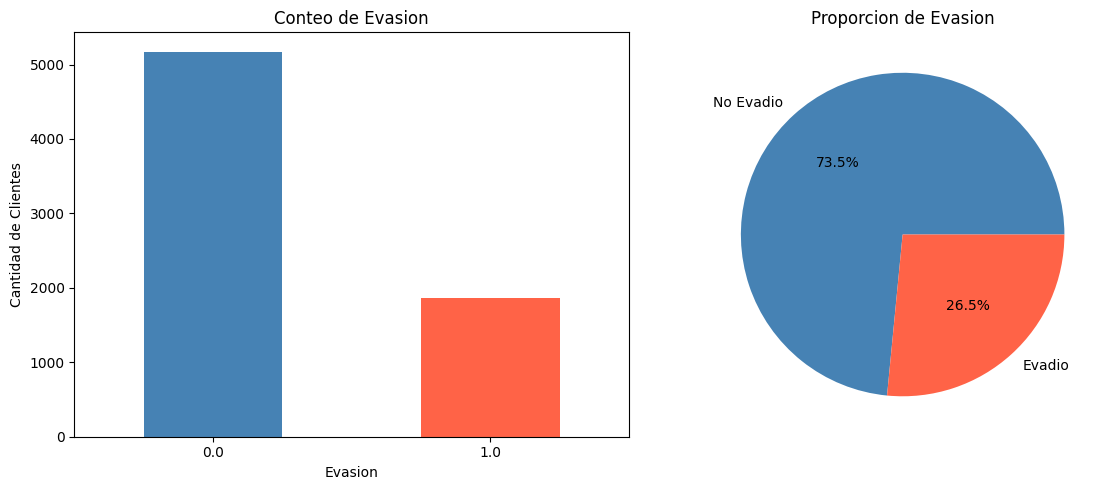

In [44]:
conteo = df_clean['Evasion'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conteo.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Conteo de Evasion')
axes[0].set_ylabel('Cantidad de Clientes')

axes[1].pie(conteo, labels=['No Evadio','Evadio'],
            autopct='%1.1f%%', colors=['steelblue','tomato'])
axes[1].set_title('Proporcion de Evasion')
plt.tight_layout()
plt.show()

<h4 align='center'> Variables categoricas </h4>

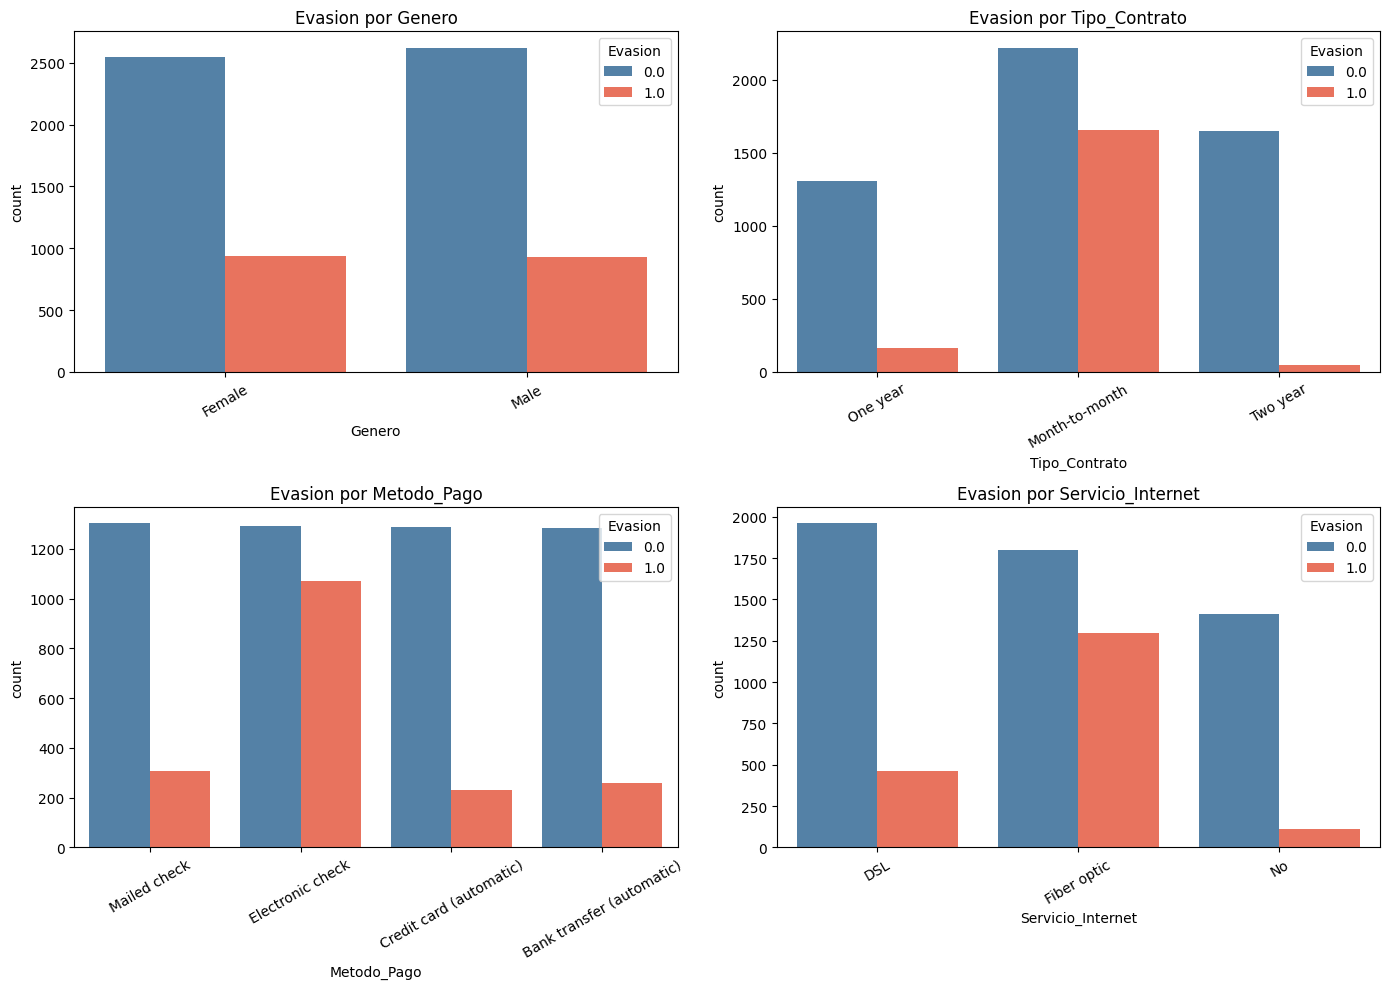

In [45]:
categoricas = ['Genero', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df_clean, x=col, hue='Evasion',
                  palette=['steelblue','tomato'], ax=axes[i])
    axes[i].set_title(f'Evasion por {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

<h4 align='center'> Variables numericas </h4>

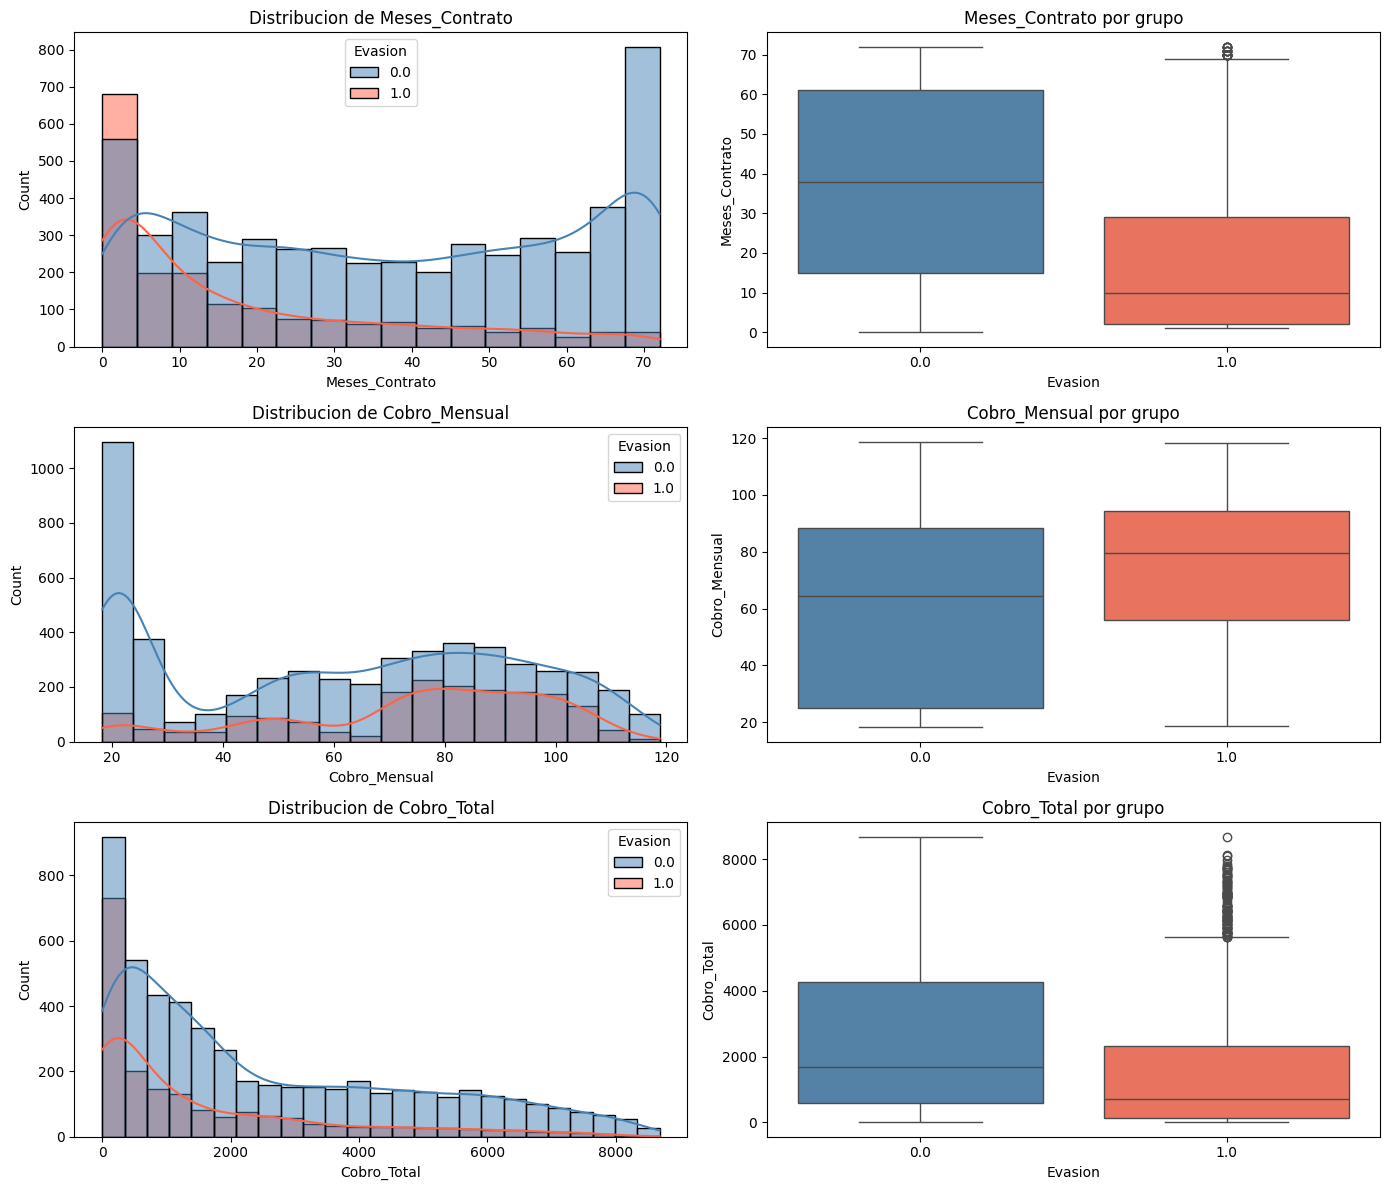

In [46]:
numericas = ['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total']
fig, axes = plt.subplots(len(numericas), 2, figsize=(14, 12))

for i, col in enumerate(numericas):
    sns.histplot(data=df_clean, x=col, hue='Evasion',
                 palette=['steelblue','tomato'], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'Distribucion de {col}')
    
    sns.boxplot(data=df_clean, x='Evasion', y=col,
                hue='Evasion', palette=['steelblue','tomato'],
                legend=False, ax=axes[i,1])
    axes[i,1].set_title(f'{col} por grupo')

plt.tight_layout()
plt.show()

<h3 align='center'> EXTRA </h3>

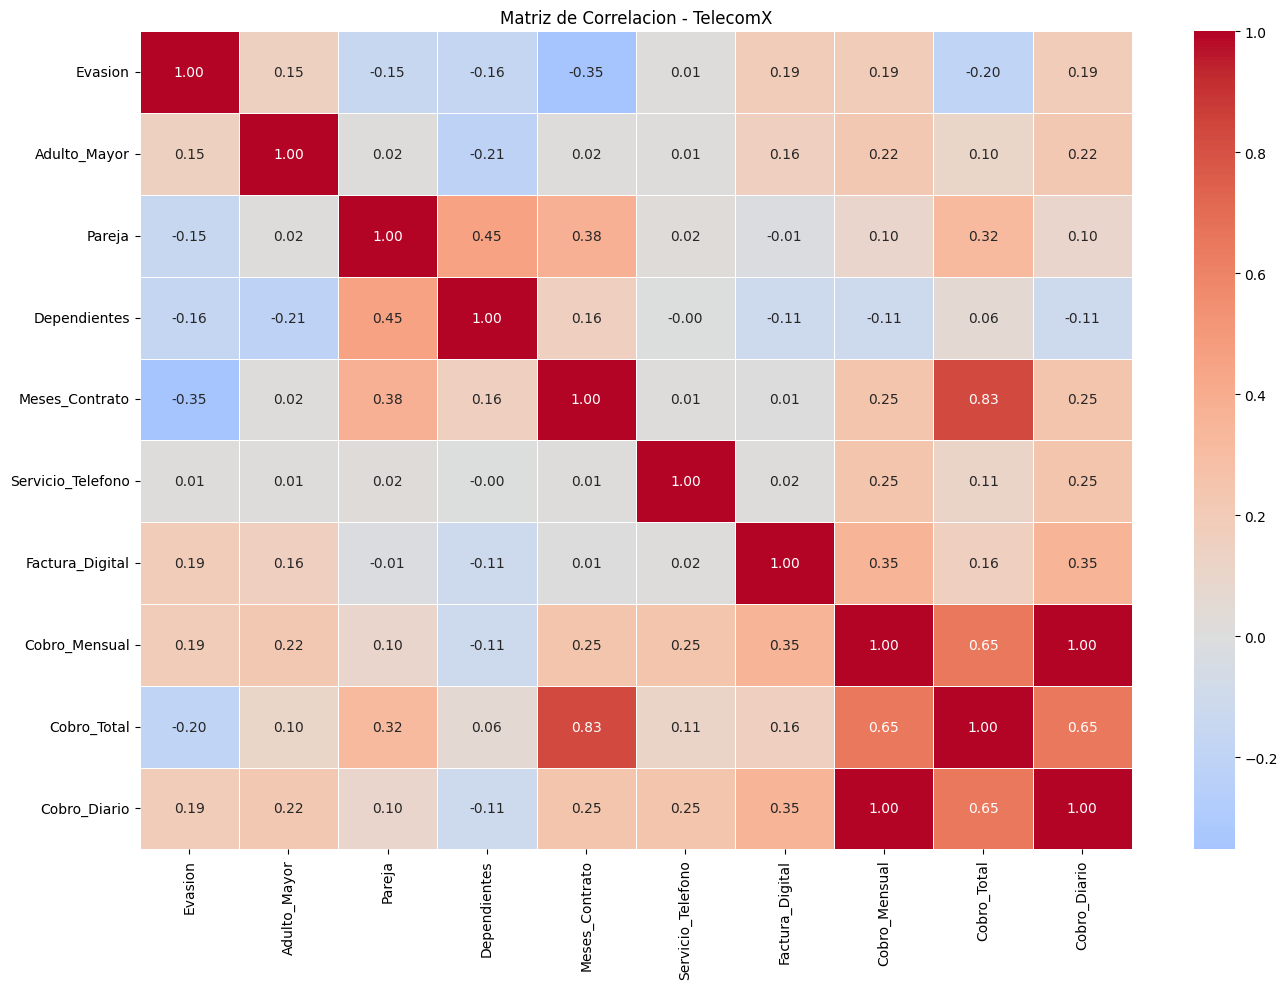


Correlacion con Evasion:
Evasion              1.000000
Cobro_Diario         0.193412
Cobro_Mensual        0.193356
Factura_Digital      0.191825
Adulto_Mayor         0.150889
Servicio_Telefono    0.011942
Pareja              -0.150448
Dependientes        -0.164221
Cobro_Total         -0.198324
Meses_Contrato      -0.352229
Name: Evasion, dtype: float64


In [47]:
numericas_df = df_clean.select_dtypes(include='number')
matriz_corr = numericas_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlacion - TelecomX')
plt.tight_layout()
plt.show()

print("\nCorrelacion con Evasion:")
print(matriz_corr['Evasion'].sort_values(ascending=False))

#📄Informe final

In [49]:
# 💾 Exportar datos tratados para la Parte 2
df_clean.to_csv("datos_tratados.csv", index=False)

print("✅ Archivo exportado: datos_tratados.csv")
print(f"📐 Dimensiones: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\n🔍 Columnas exportadas:")
print(df_clean.columns.tolist())

✅ Archivo exportado: datos_tratados.csv
📐 Dimensiones: 7043 filas x 22 columnas

🔍 Columnas exportadas:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']
